# Evaluación cuantitativa de algoritmos de cambio semánticos

In [1]:
# Importar librería
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import pickle
import os
import re
import random as rn
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import bootstrap
import matplotlib.pyplot as plt
import itertools

from gensim.models import Word2Vec
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
tqdm.pandas()

In [2]:
# Configurar
load_dotenv() # Cargar las variables de entorno del archivo .env modelos_swmwosge_1008211100
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno modelos_swmwosge_50881200
modelo_dir =  RESULTADOS_DIR+ '/archivos_out/modelos_swmwosge_5051100'
pd.set_option('display.max_colwidth', None)

In [3]:
# Umbrales cables
umbral_top = 0 # antes 5 se eliminan las palabras nacional (836), creacion (628), programa (488), regimen	(485), salud (483). 
umbral_frec_menos = 2 # < antes 5 mediana de frecuencia de ocurrencia de palabra en titulos 
umbral_frec_menos_full  = 5 # antes 9 < amedia de ocurrencia de palabra en periodo de 5 años
topn_vecinos = 100

# Config modelo https://radimrehurek.com/gensim/models/word2vec.html
tam_vector = 50  # 100 Dimensionalidad de los vectores de palabras.
ventana = 5 # ventana ( int , opcional ): distancia máxima entre la palabra actual y la palabra prevista dentro de una oración.
min_frec = 2 #  Ignora todas las palabras con una frecuencia total menor que esta.
w = 1  # utilice estos muchos subprocesos de trabajo para entrenar el modelo (=entrenamiento más rápido con máquinas de múltiples núcleos).
s = 1 # Algoritmo de entrenamiento: 1 para skip-gram; de lo contrario, CBOW.
e = 100 # Número de iteraciones (épocas) en el corpus. (Anteriormente: iter )
semilla = 1 # seed ( int , opcional ): Semilla para el generador de números aleatorios. 
iteracion = 50

In [4]:
all_dfs = {}

df_names = [
    'procrustes', 
    'NN'
]

basenames = [
    'estabilidad_procrustes',
    'estabilidad_NN'
]

descriptions = [
    'Procrustes ortogonal',
    'k vecinos más cercanos'
]

flag = [
    True,
    False

]

In [5]:
# Unificamos archivos
for (i, (df_name, basename, description,f)) in enumerate(zip(df_names, basenames, descriptions,flag)):
    filename = modelo_dir+'/'+basename+'/'+basename+'_iter'+str(iteracion)+'_tam'+str(tam_vector)+'.csv'
    print('Leyendo', filename, end='...')
    df = pd.read_csv(filename)
    all_dfs[df_name] = {
        'df': df,
        'descripcion': description,
        'bandera': f
    }
    print('archivos:', df.shape)

Leyendo C:/Users/Usuario/iamas_iniciativasleg_salud/src/data//archivos_out/modelos_swmwosge_5051100/estabilidad_procrustes/estabilidad_procrustes_iter50_tam50.csv...archivos: (54650, 7)
Leyendo C:/Users/Usuario/iamas_iniciativasleg_salud/src/data//archivos_out/modelos_swmwosge_5051100/estabilidad_NN/estabilidad_NN_iter50_tam50.csv...archivos: (65200, 7)


In [6]:
# Normalizar nombres
all_dfs['procrustes']['df'].rename(
    columns={
        'top10_vecindad_t1': 'neighbors_t1', 
        'top10_vecindad_t2':'neighbors_t2'},
    inplace=True)
all_dfs['procrustes']['df'].head(1)

,iteracion,par_periodo,palabra,similaridad_semantica,cantidad_palabras_comun,neighbors_t1,neighbors_t2
0,6,"(2014, 2019)",accion,0.026791,461,"[('judicial', 0.6770266890525818), ('comunitario', 0.6661193370819092), ('julio', 0.6481040120124817), ('mental', 0.6264558434486389), ('nacimiento', 0.6204757690429688), ('valor', 0.5921574831008911), ('primario', 0.579254150390625), ('desarrollo', 0.5711088180541992), ('premio', 0.5692583322525024), ('psicologico', 0.5626101493835449)]","[('epidemiologico', 0.6849518418312073), ('promover', 0.6302334666252136), ('inter', 0.6208462119102478), ('organo', 0.6154682040214539), ('celula', 0.6115739941596985), ('tratamiento', 0.6076741218566895), ('nivel', 0.5620438456535339), ('donacion', 0.5555312633514404), ('padecer', 0.554180383682251), ('investigacion', 0.538840115070343)]"


In [7]:
#print(all_dfs['procrustes']['df']['par_periodo'].unique())

In [8]:
# Normalizar
all_dfs['NN']['df'].rename(
    columns={
        'topn_vecindad_t1': 'neighbors_t1', 
        'topn_vecindad_t2': 'neighbors_t2'},
    inplace=True)
all_dfs['NN']['df'].head(1)

,iteracion,par_periodo,palabra,similaridad_semantica,cantidad_palabras_comun,neighbors_t1,neighbors_t2
0,16,"(2009, 2014)",radiacion,0,0,"['perjudicial', 'efecto', 'diabetico', 'fondo', 'adolescente', 'apto', 'edad', 'tabaco', 'cancer', 'saludable', 'historia', 'victima']","['espacio', 'desfibrilador', 'leyenda', 'identificacion', 'celiaca', 'automatico', 'exhibicion', 'acceso', 'cualquiera', 'gluten', 'difusion', 'rehabilitacion', 'accidente', 'externo', 'contenido', 'diagnostico']"


In [9]:
#print(all_dfs['NN']['df']['par_periodo'].unique())

Aplicamos la comparación a la tarea de detección de cambios en el uso de palabras primero para los pareas 2009-2014 y 2014-2019 y luego, para 2014-2019 y 2019-2024. 

* Periodo 2009 = [2009,2014) = [127,131] # el período parlamentario 127 inicia el 01/03/2009
* Período 2014 = [2014,2019) = [132,136] # 132 inicia el 01/03/2014
* Período 2019 = [2019,2024) = [137,141] # 137 inicia el 01/03/2019


Utilizamos la intersección @k, propuesta por Gonen et al., que mide el porcentaje de palabras compartidas en las k palabras más cambiadas durante varios reinicios, cambiando cada vez la semilla aleatoria.




Para cada enfoque (p. ej., procrustes) y entre los dos períodos, medimos el cambio en el uso de palabras y detectamos las palabras más cambiadas. Al repetir la medición con diferentes semillas aleatorias (50 iteraciones), calculamos las palabras comunes cambiadas en las repeticiones. Específicamente, ejecutamos cada enfoque de cambio de uso y recopilamos las k palabras más cambiadas, donde k ∈ k = [10, 25, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600,650,700,750,800]
. Luego, para cada uno de los (50 2 )= Combinaciones de 50 elementos tomados de 2 en 2 = 1225  pares de ejecuciones diferentes y para cada uno de los valores de k, medimos el porcentaje de palabras compartidas en las predicciones de palabras con mayor cambio de cada enfoque. Un valor de cero entre un par de ejecuciones significa que no hay palabras compartidas en sus predicciones, lo que indica alta variabilidad, mientras que un valor de uno indica alta estabilidad.

In [10]:
iteracion

50

In [11]:
k = [10, 25, 50, 75, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600,650,700,750,800]
all_pairs = list(itertools.combinations(range(iteracion), 2))
#print(len(k))
#print(all_pairs)

In [12]:
# n! / (r! * (n - r)!) 
print(len(all_pairs))


1225


In [13]:
estabilidad_k = {}
for par_periodo in ['(2009, 2014)','(2014, 2019)']: 
    estabilidad_k[par_periodo]= {}
    print(par_periodo)
    for method_name, method_results in all_dfs.items(): 
        print(method_name)
        label = method_results['descripcion']
        
        df = method_results['df']
        df = df[df['par_periodo']== par_periodo]
                
        flag = method_results['bandera']
        
        X = []
        Y = []
        
        yerr = [
        [], # lower errors
        [] # upper errors
        ]
        for n in k:
            intersection_per_pair = np.zeros(len(all_pairs))

            for i, pair in enumerate(all_pairs):

                iteration_0_topk = df.loc[(df.iteracion==pair[0])].sort_values('similaridad_semantica', ascending=flag)['palabra'][:n]
                iteration_1_topk = df.loc[(df.iteracion==pair[1])].sort_values('similaridad_semantica', ascending=flag)['palabra'][:n]
                intersection = len(set(iteration_0_topk).intersection(set(iteration_1_topk)))
                intersection_per_pair[i] = intersection / n #jaccard

            intersection_at_k = np.mean(intersection_per_pair)
            Y.append(intersection_at_k)
            X.append(n)
            res = bootstrap((intersection_per_pair,), np.mean, confidence_level=0.95)
            yerr[0].append(intersection_at_k - res.confidence_interval.low)
            yerr[1].append(res.confidence_interval.high - intersection_at_k)

        dic = {'k':X, 'promedio interseccion k ': Y, 'errores inferiores': yerr[0], 'errores superiores': yerr[1]}
        estabilidad_k[par_periodo][label] = dic


(2009, 2014)
procrustes


C:\Users\Usuario\iamas_iniciativasleg_salud\myenv_IL\Lib\site-packages\scipy\stats\_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_42168\2059284926.py:34: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  res = bootstrap((intersection_per_pair,), np.mean, confidence_level=0.95)


NN
(2014, 2019)
procrustes
NN


* Intersección @k: mide el porcentaje de palabras compartidas en las predicciones de k palabras con mayor cambio por par de ejecuciones.

    * Valor cercano a 1.0 : alta estabilidad, resultados consistentes.
    * Valor cercano a 0.0 : alta variabilidad, resultados sensibles a la semilla.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_42168\1920418271.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_labels)) # Elegimos un mapa de colores y obtenemos los colores necesarios


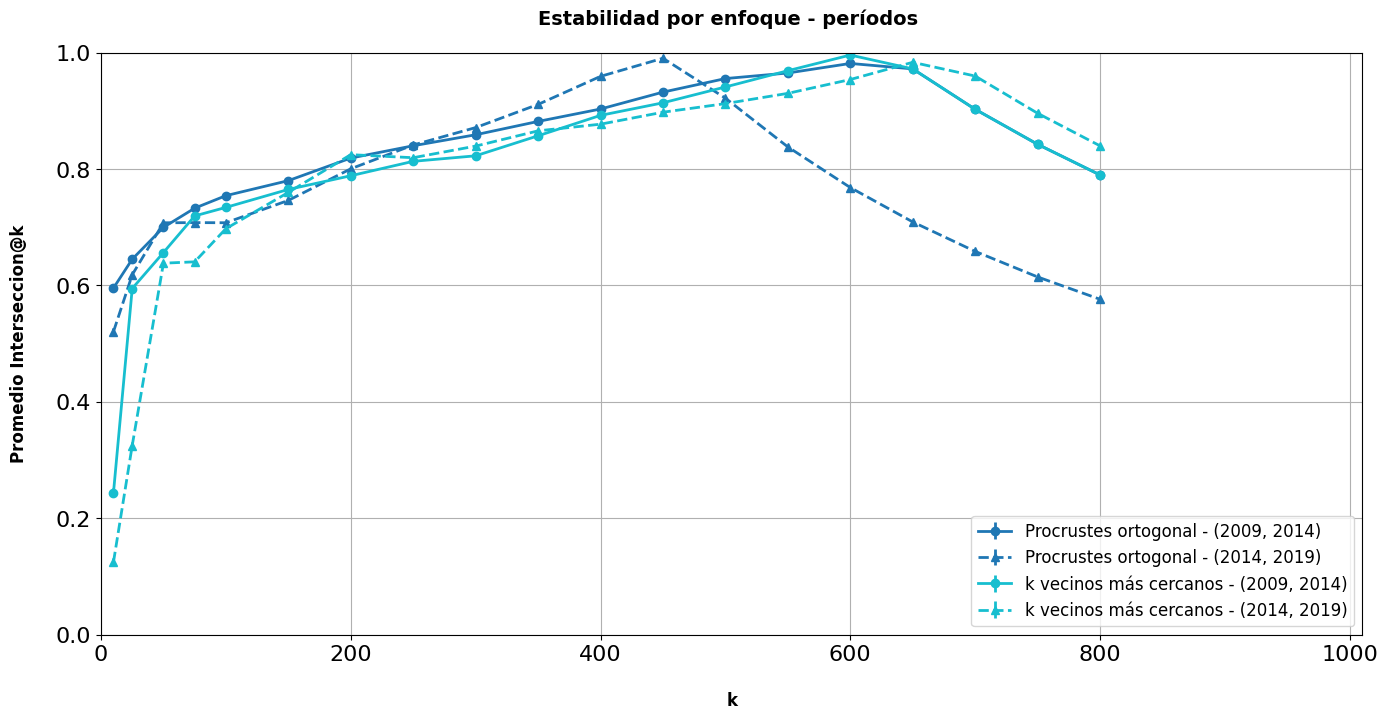

In [15]:
fig = plt.figure(figsize=(14, 8))
line_styles = {'(2009, 2014)': '-o', '(2014, 2019)': '--^'}
unique_labels = sorted(list(set(k for periodo_data in estabilidad_k.values() for k in periodo_data.keys())))
colors = plt.cm.get_cmap('tab10', len(unique_labels)) # Elegimos un mapa de colores y obtenemos los colores necesarios
color_map = {label: colors(i) for i, label in enumerate(unique_labels)}

for i, label in enumerate(unique_labels):
    for par_periodo, dic in estabilidad_k.items():
        if label in dic:
            datos = dic[label]
            X = datos['k']
            Y = datos['promedio interseccion k ']
            yerr = [datos['errores inferiores'], datos['errores superiores']]
            plt.errorbar(X, Y, yerr=yerr, label=f'{label} - {par_periodo}', linewidth=2, fmt=line_styles[par_periodo], color=color_map[label])

plt.gca().tick_params(axis='both', which='major', labelsize=16)
plt.ylim(0, 1)
plt.xlim(0, 1010)
plt.xlabel('k', fontsize=12, 
              fontweight='bold', 
              labelpad=20)
plt.ylabel('Promedio Ιnterseccion@k', fontsize=12, 
              fontweight='bold', 
              labelpad=20)
plt.title('Estabilidad por enfoque - períodos ', fontsize=14, fontweight='bold', pad=20)
plt.legend(fontsize=12)
plt.grid(True)
# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
# Guardar en alta calidad para accesibilidad
plt.savefig(BASE_DIR+'imagenes/estabilidad_modelosAlineacion.png', 
            dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()

**Enfoque de procruste genera estos resultados:**

Entrenando modelos por período de 5 años...
* 0it [00:00, ?it/s]Período: 2009
Tamaño corpus: 776
* 1it [00:01,  1.78s/it]Período: 2014
Tamaño corpus: 1009
* 2it [00:04,  2.11s/it]Período: 2019
Tamaño corpus: 1063

Modelo alineado guardado
* Alineando período: 2009
* Alineando período: 2014 632 palabras únicas
* Alineando período: 2019 461 palabras únicas

**Enfoque NN :**

Entrenando modelos por período de 5 años...
* 0it [00:00, ?it/s]Período: 2009
Tamaño corpus: 776

* 1it [00:02,  2.61s/it]Período: 2014
Tamaño corpus: 1009

* 2it [00:05,  3.03s/it]Período: 2019
Tamaño corpus: 1063

* 3it [00:09,  3.18s/it]

* Cargando período: 2009
vecindades calculadas  (0, 2009)
* Cargando período: 2014
Cantidad Final lista de palabras:  632
vecindades calculadas  (2009, 2014)
* Cargando período: 2019
Cantidad Final lista de palabras:  672
vecindades calculadas  (2014, 2019)


In [16]:
estab_df['k'].unique() # Recordando k -

array([ 10,  25,  50,  75, 100, 150, 200, 250, 300, 350, 400, 450, 500,
       550, 600, 650, 700, 750, 800], dtype=int64)

In [17]:
print("Promedio por periodo")
estab_df.groupby(['periodo'])['promedio interseccion k'].mean().reset_index().sort_values(['promedio interseccion k'], ascending=False)


Promedio por periodo


,periodo,promedio interseccion k
0,"(2009, 2014)",0.817671
1,"(2014, 2019)",0.769956


In [18]:
print("Promedio por periodo")
estab_df.groupby(['metodo'])['promedio interseccion k'].mean().reset_index().sort_values(['promedio interseccion k'], ascending=False)


Promedio por periodo


,metodo,promedio interseccion k
0,Procrustes ortogonal,0.798033
1,k vecinos más cercanos,0.789594


In [19]:
print("Promedio por periodo y método")
estab_df.groupby(['periodo', 'metodo'])['promedio interseccion k'].mean().reset_index().sort_values(['promedio interseccion k'], ascending=False)


Promedio por periodo y método


,periodo,metodo,promedio interseccion k
0,"(2009, 2014)",Procrustes ortogonal,0.834442
1,"(2009, 2014)",k vecinos más cercanos,0.800900
3,"(2014, 2019)",k vecinos más cercanos,0.778289
2,"(2014, 2019)",Procrustes ortogonal,0.761623


In [20]:
print("Promedio por K")
k_mean_df = estab_df.groupby(['k'])['promedio interseccion k'].mean().reset_index().sort_values(['promedio interseccion k'], ascending=False)
k_mean_df.head(10) # top 100

Promedio por K


,k,promedio interseccion k
11,450,0.933697
12,500,0.932878
13,550,0.925709
14,600,0.925028
15,650,0.909370
10,400,0.908116
9,350,0.879085
16,700,0.856071
8,300,0.848232
7,250,0.828662


Consideramos que el k más estable globalmente es el k que muestra menor variación (diferencia entre máximo y mínimo) en el promedio de intersección k para los distintos métodos y períodos. Para k<500


In [21]:
# Agrupar por k y calcular el rango (max - min) de la métrica
rangos_k = (
    estab_df.groupby('k')['promedio interseccion k']
    .agg(['min', 'max'])
    .assign(rango=lambda d: d['max'] - d['min'])
    .reset_index()
)

rangos_k = rangos_k[rangos_k['k']<500]
# Obtener el k con menor rango
k_menor_rango = rangos_k.loc[rangos_k['rango'].idxmin(), 'k']
rango_minimo = rangos_k['rango'].min()

print(f"El k con menor rango de 'promedio interseccion k' entre enfoques y períodos es: {k_menor_rango}")
print(f"Con un rango de: {rango_minimo:.6f}")

El k con menor rango de 'promedio interseccion k' entre enfoques y períodos es: 250
Con un rango de: 0.028069


In [22]:
rangos_k.sort_values('rango')

,k,min,max,rango
7,250,0.813401,0.841469,0.028069
5,150,0.746226,0.780201,0.033976
6,200,0.788612,0.824853,0.036241
8,300,0.822887,0.871388,0.048501
9,350,0.857301,0.911249,0.053948
4,100,0.697608,0.754376,0.056767
2,50,0.638302,0.707755,0.069453
10,400,0.877259,0.959478,0.082218
3,75,0.640620,0.732844,0.092223
11,450,0.897834,0.990587,0.092753


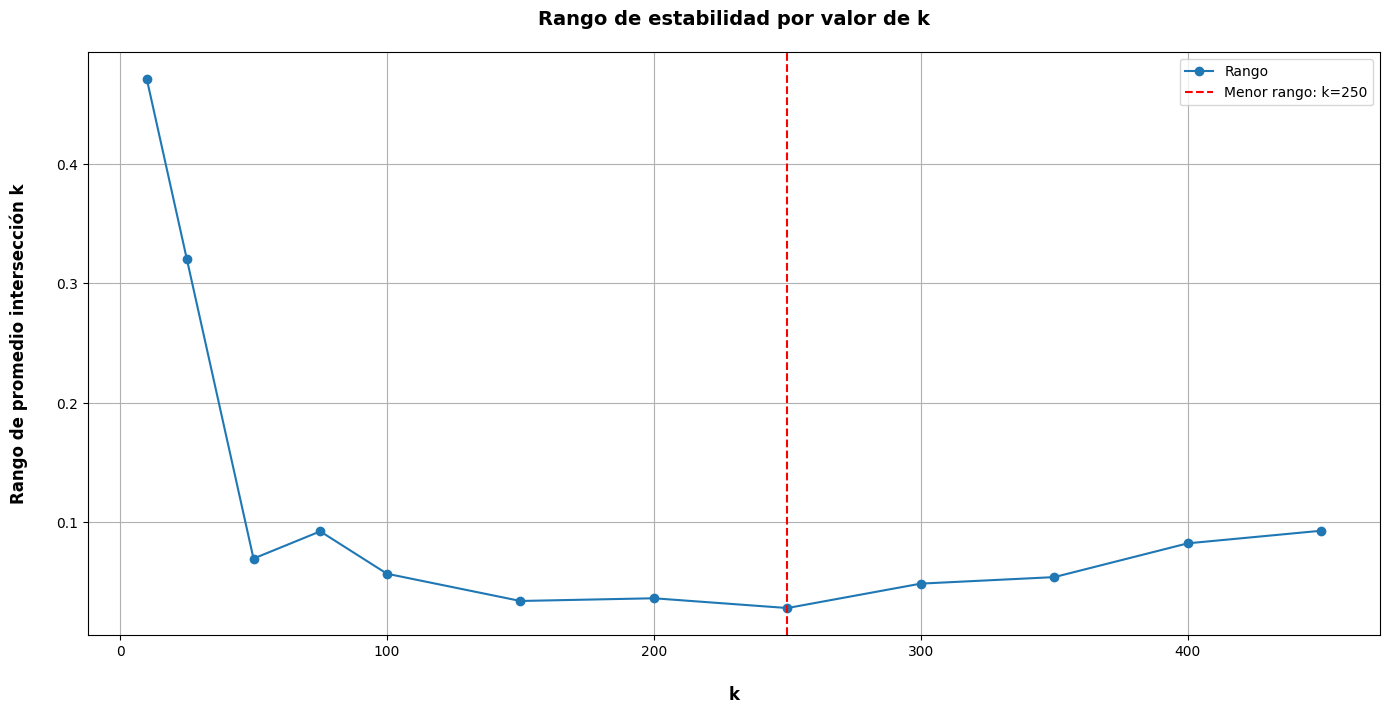

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))
plt.plot(rangos_k['k'], rangos_k['rango'], marker='o', label='Rango')
plt.axvline(k_menor_rango, color='red', linestyle='--', label=f'Menor rango: k={k_menor_rango}')
plt.title('Rango de estabilidad por valor de k',fontsize=14, fontweight='bold', pad=20)
plt.xlabel('k',fontsize=12, 
              fontweight='bold', 
              labelpad=20)
plt.ylabel('Rango de promedio intersección k', fontsize=12, 
              fontweight='bold', 
              labelpad=20)
plt.legend()
plt.grid(True)

# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
# Guardar en alta calidad para accesibilidad
plt.savefig(BASE_DIR+'imagenes/rango_estabilidadValorK.png', dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()



In [24]:
estab_df.sort_values(by='promedio interseccion k', ascending=False)

,periodo,metodo,k,promedio interseccion k,errores inferiores,errores superiores
33,"(2009, 2014)",k vecinos más cercanos,600,0.996094,0.000088,0.000087
49,"(2014, 2019)",Procrustes ortogonal,450,0.990587,0.000155,0.000147
72,"(2014, 2019)",k vecinos más cercanos,650,0.983632,0.000142,0.000139
14,"(2009, 2014)",Procrustes ortogonal,600,0.981657,0.000200,0.000197
34,"(2009, 2014)",k vecinos más cercanos,650,0.972308,0.000000,0.000000
...,...,...,...,...,...,...
56,"(2014, 2019)",Procrustes ortogonal,800,0.576250,NaN,NaN
38,"(2014, 2019)",Procrustes ortogonal,10,0.520653,0.006531,0.006449
58,"(2014, 2019)",k vecinos más cercanos,25,0.324865,0.006807,0.006792
19,"(2009, 2014)",k vecinos más cercanos,10,0.244000,0.007592,0.007673



La figura y las tablas de resultados muestran la intersección promedio @k entre los 1225 pares de ejecuciones diferentes para cada enfoque y periodo, con intervalos de confianza del 95 % calculados mediante el método bootstrap. 

Los valores de k entre 200 a 450, brindan valores de intersección promedio en crecimiento y superior a 0.8 para los diferentes enfoques. Un valor superior a 0.8 indica un alto valor de solapamiento entre las k palabras más cambiadas identificadas por múltiples ejecuciones del modelo con diferentes inicializaciones aleatorias. 

Se observa que el método Procrustes ortogonal presenta mayor estabilidad general con errores reducidos, especialmente para k ≤ 450. 

 * La intersección promedio de procruste es 0.81 versus 0.79 de NN. 
 * La media de intersección es de 0.82 para 2009–2014 y 0.77 para 2014–2019, frente a valores inferiores y más variables en el método de NN.
 * Procrustes presentó intervalos de confianza estrechos (<0.002), lo que refuerza su confiabilidad para comparaciones diacrónicas de vocabulario legislativo.

Estabilidad por período:
La comparación entre 2009–2014 es más estable que entre 2014–2019 para ambos métodos, lo que podría indicar:
* Un cambio semántico más abrupto o disperso en el segundo período.
* Mayor ruido o complejidad semántica en la producción legislativa 2014–2019 (Pandemia).

Se tomará **k= 250** para evaluar cualitativamente los enfoques y los períodos, porque tiene mayor 'promedio interseccion k' y  menor valor de variacion.

### Palabras más cambiadas por período de 5 años

In [25]:
#print(all_dfs['NN']['df']['par_periodo'].unique())
#print(all_dfs['procrustes']['df']['par_periodo'].unique())
pares_periodo = [ (2009, 2014),(2014, 2019)]
pares_periodo

[(2009, 2014), (2014, 2019)]

In [26]:
''' para verificar
# Frecuencia de palabras por período
df = all_dfs['NN']['df']
par_periodo = (2009, 2014)
df = df[df['par_periodo'] == str(par_periodo)]
flag = all_dfs['NN']['bandera']
frecPer1 = pd.read_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[0])+'.csv')
frecPer2 = pd.read_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[1])+'.csv')
frecPer1.columns = ['palabra', 'frec1', 'porc1']
frecPer2.columns = ['palabra', 'frec2', 'porc2']
df = df[df['par_periodo'] == str(par_periodo)]
df.head(2)
'''

" para verificar\n# Frecuencia de palabras por período\ndf = all_dfs['NN']['df']\npar_periodo = (2009, 2014)\ndf = df[df['par_periodo'] == str(par_periodo)]\nflag = all_dfs['NN']['bandera']\nfrecPer1 = pd.read_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[0])+'.csv')\nfrecPer2 = pd.read_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[1])+'.csv')\nfrecPer1.columns = ['palabra', 'frec1', 'porc1']\nfrecPer2.columns = ['palabra', 'frec2', 'porc2']\ndf = df[df['par_periodo'] == str(par_periodo)]\ndf.head(2)\n"

### Evaluación cualitativa: Palabras con mayor cambio entre pares [2009-2014) y [2014-2019) y [2014-2019) a  [2019-2024)
Se realizaron 50 ejecuciones independientes del enfoque Procrustes, cada una con una semilla aleatoria distinta. En cada iteración, se seleccionaron las 200 palabras con mayor cambio semántico entre los pares de períodos comparados, considerando únicamente aquellas con al menos 5 ocurrencias en alguno de los dos períodos de cinco años.

Posteriormente, se calculó la intersección promedio de las palabras identificadas en el top 200 de cada ejecución, como medida de estabilidad del modelo. Este valor fue estimado junto con sus respectivos intervalos de confianza del 95%, utilizando el método bootstrap.




In [27]:
n = 250
at_least_in_any_decade = 5

csvs = []
topn_periodo_dic = {}
for par_periodo in  [(2009, 2014),(2014, 2019)]:
    
    enfoque_topn = {} 
    for method_name, method_results in all_dfs.items(): 

        print(method_name)
        label = method_results['descripcion']
        df = method_results['df']
        df = df[df['par_periodo']== str(par_periodo)]
        flag = method_results['bandera']

        frecPer1 = pd.read_csv(RESULTADOS_DIR+'archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[0])+'.csv')
        frecPer2 = pd.read_csv(RESULTADOS_DIR+'archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(par_periodo[1])+'.csv')
        frecPer1 = frecPer1[['Palabra',	'Frecuencia','Porcentaje']]
        frecPer2 = frecPer2[['Palabra',	'Frecuencia','Porcentaje']]
        frecPer1.columns = ['palabra', 'frec1', 'porc1']
        frecPer2.columns = ['palabra', 'frec2', 'porc2']
        print(frecPer1.shape)
        print(frecPer2.shape)
        print(frecPer1)
    
        df_topn = df.loc[(df.iteracion==0)]
        #controlar frec
        df_topn = df_topn.merge(frecPer1, how='left', on='palabra')
        df_topn = df_topn.merge(frecPer2, how='left', on='palabra')

        
        df_topn['max_freq_of_any_decade'] = df_topn[['frec1', 'frec2']].max(axis=1)
        df_topn.drop(['frec1', 'frec2', 'porc1', 'porc2'], axis=1, inplace=True) 
        df_topn = df_topn.loc[df_topn.max_freq_of_any_decade>= at_least_in_any_decade].head(n)
        df_topn = df_topn[['palabra','similaridad_semantica','neighbors_t1', 'neighbors_t2']].sort_values('similaridad_semantica', ascending=flag).head(n)
        enfoque_topn[method_name] = df_topn
        
        new_name = method_name.lower().replace(' ', '_')
        new_name = new_name.replace('-', '')
        new_periodo = str(par_periodo)
        new_periodo = new_periodo.replace('(', '')
        new_periodo = new_periodo.replace(')', '')
        new_periodo = new_periodo.replace(',', '_')
        
        csv_path = modelo_dir+'/'+new_name+'_periodo'+str(new_periodo)+'_top'+str(n)+'.csv'
        #csvs.append(csv_path)

        df_topn.to_csv(csv_path, index=False)
        csvs.append(df_topn)

    topn_periodo_dic[par_periodo] = enfoque_topn

procrustes
(1717, 3)
(1969, 3)
             palabra  frec1     porc1
0                xii      1  0.000127
1               ipod      1  0.000127
2               desa      1  0.000127
3     semiautomatico      1  0.000127
4         patagonico      1  0.000127
...              ...    ...       ...
1712          social    110  0.013974
1713        programa    112  0.014228
1714           salud    133  0.016895
1715        creacion    157  0.019944
1716        nacional    208  0.026423

[1717 rows x 3 columns]
NN
(1717, 3)
(1969, 3)
             palabra  frec1     porc1
0                xii      1  0.000127
1               ipod      1  0.000127
2               desa      1  0.000127
3     semiautomatico      1  0.000127
4         patagonico      1  0.000127
...              ...    ...       ...
1712          social    110  0.013974
1713        programa    112  0.014228
1714           salud    133  0.016895
1715        creacion    157  0.019944
1716        nacional    208  0.026423

[1717 ro

(2009, 2014)
Procrustes:  {'legal', 'materia', 'argentina', 'utilizacion', 'acompanante', 'pre', 'declaracion', 'empleo', 'ingreso', 'territorio'}
NN: {'legal', 'premio', 'materia', 'dengue', 'evaluacion', 'acompanante', 'mental', 'periodo', 'psicologico', 'precio'}
(2014, 2019)
Procrustes:  {'forma', 'adecuado', 'violencia', 'domiciliario', 'necesario', 'dispositivo', 'trabajador', 'comunitario', 'educacion', 'ingreso'}
NN: {'academia', 'preventivo', 'esencial', 'dispositivo', 'dependencia', 'comunitario', 'muscular', 'adquirido', 'precio', 'central'}


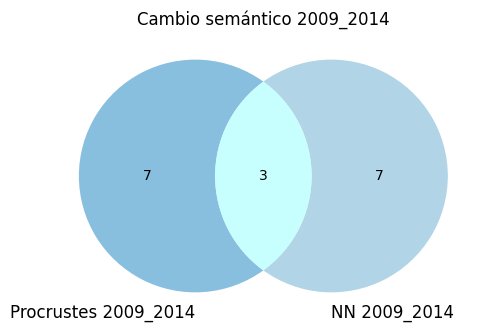

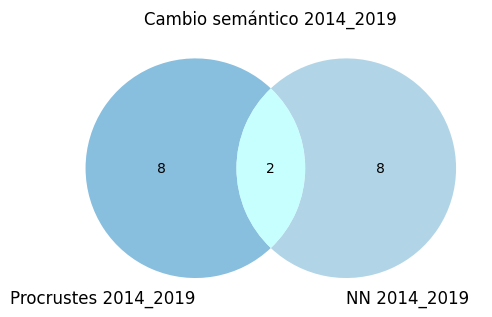

In [28]:
from matplotlib_venn import venn2
K= 10
seman_dic = {}
for periodo, dicTop in topn_periodo_dic.items():
    print(periodo)
    seman_dic['Procrustes_'+str(periodo[0])+'_'+str(periodo[1])] = set(pal[0] for pal in dicTop['procrustes'][['palabra']].head(K).values)
    seman_dic['NN_'+str(periodo[0])+'_'+str(periodo[1])] = set(pal[0] for pal in dicTop['NN'][['palabra']].head(K).values)

    #display(dicTop['procrustes'].head(K))
    print("Procrustes: ",seman_dic['Procrustes_'+str(periodo[0])+'_'+str(periodo[1])])
    print("NN:",seman_dic['NN_'+str(periodo[0])+'_'+str(periodo[1])])
    # Crear la figura
    plt.figure(figsize=(12, 5))
    # Diagrama Venn para 2009–2014
    plt.subplot(1, 2, 1)
    venn2([seman_dic['Procrustes_'+str(periodo[0])+'_'+str(periodo[1])], seman_dic['NN_'+str(periodo[0])+'_'+str(periodo[1])]],
      set_labels=('Procrustes '+str(periodo[0])+'_'+str(periodo[1]), 'NN '+str(periodo[0])+'_'+str(periodo[1])),
      set_colors=('#6baed6', '#9ecae1'), alpha=0.8)
    plt.title('Cambio semántico '+str(periodo[0])+'_'+str(periodo[1]))
    

Procrustes → compara la posición global de la palabra en dos espacios alineados.
NN → compara la estructura local de vecinos semánticos alrededor de la palabra.
* Hay solapamiento parcial ("acompanante", "materia", "legal", "dispositivo" y "comunitario" aparecen en ambos enfoques).

* Período: (2009, 2014)
    * Procrustes detecta más términos institucionales, jurídicos y administrativos que NN (legal, declaración,  materia, ingreso). "acompanante", "materia", "legal" aparece en ambos métodos
    * NN capta conceptos de salud pública (dengue, mental).
* Período: (2014, 2019)
    * Ambos métodos coinciden en palabras como: "comunitario", y "dispotivo". 
